In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the titanic training dataset
df = pd.read_csv('../data/train.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.shape


(891, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

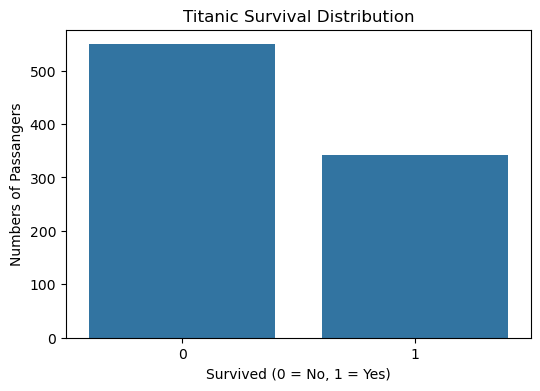

In [12]:
# VIsualize the overall distrbution of passangers who survived and did not survive
plt.figure(figsize=(6,4))

sns.countplot(x="Survived",data=df)

plt.title("Titanic Survival Distribution")

plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Numbers of Passangers")

plt.show()

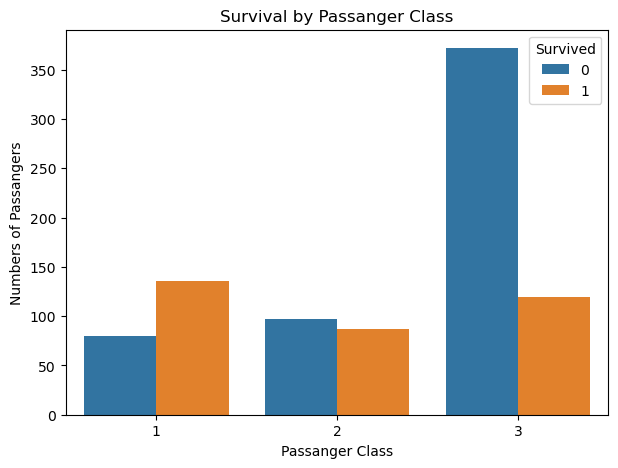

In [14]:
# Compare survival and death rates across passangers classes

plt.figure(figsize=(7,5))

sns.countplot(x="Pclass",hue="Survived",data=df)

plt.title("Survival by Passanger Class")
plt.xlabel("Passanger Class")
plt.ylabel("Numbers of Passangers")

plt.show()

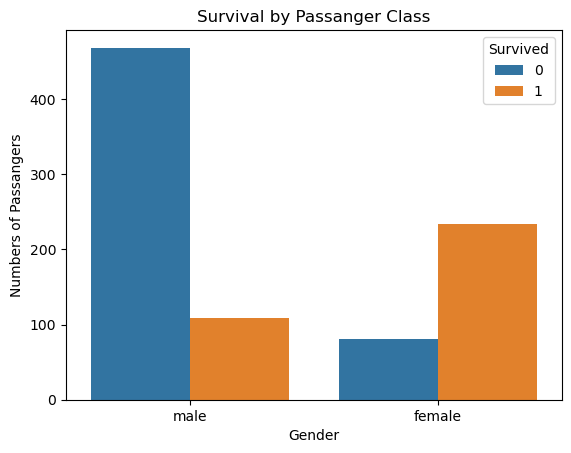

In [17]:
# Analyze the reletionship between passanger gender and survival 

sns.countplot(data=df,x='Sex',hue="Survived")

plt.title("Survival by Passanger Class")
plt.xlabel("Gender")
plt.ylabel("Numbers of Passangers")

plt.show()


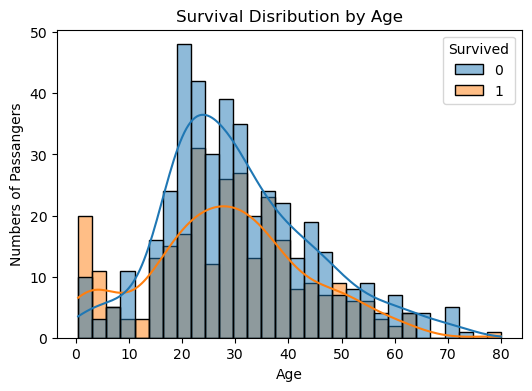

In [20]:
# Analyze the  relationship between Passanger age and survival 

plt.figure(figsize=(6,4))

sns.histplot(data=df,x= 'Age',
             hue='Survived',
             bins=30,kde=True)

plt.title("Survival Disribution by Age")

plt.xlabel("Age")
plt.ylabel("Numbers of Passangers")

plt.show()


In [23]:
# check the number of missing value in each column 

missing_values = df.isnull().sum()

print(missing_values)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [28]:
# Fill missing Age values with the median age

df['Age'] = df['Age'].fillna(df['Age'].median())

print("Missing Age values handled successfully!")

Missing Age values handled successfully!


In [29]:
# Fill missing Embarked values with the most common part

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing Embarked values handled Successfully!")

Missing Embarked values handled Successfully!


In [36]:
# Convert categorical columns (Sex and Embarked) into numerical values
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

print("Categorical columns converted successfully!")
print(df.head())

Categorical columns converted successfully!
   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  71.2833     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [37]:
# Check the final dataset structure before building the model 

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB
None


In [38]:
# Separate input features (X) from the target variable (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

print("Features (X) and target (y) separated successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features (X) and target (y) separated successfully!
X shape: (891, 8)
y shape: (891,)


In [39]:
# Split the dataset into 80% training data and 20% testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split successfully!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Data split successfully!
Training data: (712, 8)
Testing data: (179, 8)


In [40]:
# Train a Logistic Regression model using the training data

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [41]:
# Evaluate the Logistic Regression model on the unseen testing data

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Logistic Regression Accuracy: 0.8044692737430168
Accuracy Percentage: 80.45 %


In [42]:
# Train a Decision Tree model using the training data

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [44]:
# Evaluate the Decision Tree model on the unseen testing data

tree_pred = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)
print("Accuracy Percentage:", round(tree_accuracy * 100, 2), "%")

Decision Tree Accuracy: 0.7653631284916201
Accuracy Percentage: 76.54 %


In [45]:
# Compare the accuracy of Logistic Regression and Decision Tree models

print("Logistic Regression Accuracy:",
      round(accuracy * 100, 2), "%")

print("Decision Tree Accuracy:",
      round(tree_accuracy * 100, 2), "%")

if tree_accuracy > accuracy:
    print("Decision Tree performed better.")
else:
    print("Logistic Regression performed better.")

Logistic Regression Accuracy: 80.45 %
Decision Tree Accuracy: 76.54 %
Logistic Regression performed better.


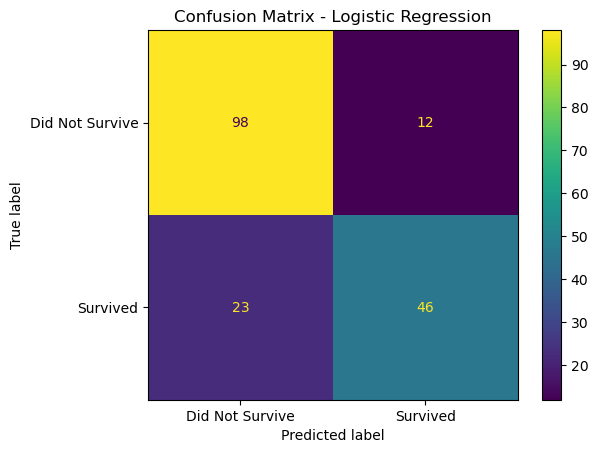

In [46]:
# Create a confusion matrix for the better-performing model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if tree_accuracy > accuracy:
    best_model = tree_model
    best_pred = tree_pred
    best_model_name = "Decision Tree"
else:
    best_model = model
    best_pred = y_pred
    best_model_name = "Logistic Regression"

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [47]:
# Generate a detailed classification report for the best model

from sklearn.metrics import classification_report

print("Best Model:", best_model_name)
print()
print(classification_report(y_test, best_pred))

Best Model: Logistic Regression

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [48]:
# Analyze which passenger features are most important in the Decision Tree

feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Sex_male      0.530655
Pclass        0.180404
Age           0.129043
Fare          0.113752
Embarked_S    0.034252
SibSp         0.011150
Parch         0.000745
Embarked_Q    0.000000
dtype: float64


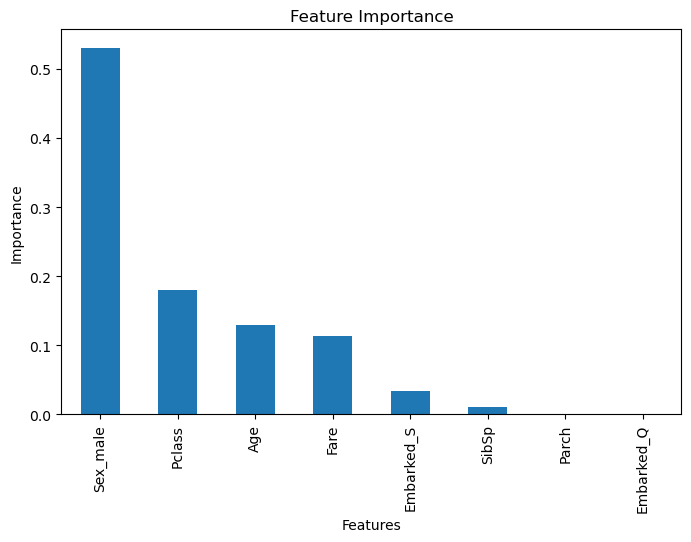

In [49]:
# Visualize the importance of each passenger feature

plt.figure(figsize=(8, 5))

feature_importance.plot(kind='bar')

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [50]:
# Load the Titanic test dataset for making final survival predictions

test_df = pd.read_csv("../data/test.csv")

print("Test dataset loaded successfully!")
print(test_df.head())

Test dataset loaded successfully!
   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  


In [51]:
# Check the structure and missing values in the Titanic test dataset

print(test_df.info())
print()
print(test_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [52]:
# Save PassengerId values for the final prediction file

passenger_ids = test_df['PassengerId'].copy()

print("Passenger IDs saved successfully!")

Passenger IDs saved successfully!


In [53]:
# Clean the test dataset using the same preprocessing approach as the training data

test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])

test_df = test_df.drop(
    ['PassengerId', 'Name', 'Ticket', 'Cabin'],
    axis=1
)

print("Test dataset cleaned successfully!")

Test dataset cleaned successfully!


In [54]:
# Convert categorical columns in the test dataset into numerical values

test_df = pd.get_dummies(
    test_df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

print("Test categorical columns converted successfully!")
print(test_df.head())

Test categorical columns converted successfully!
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  34.5      0      0   7.8292      True        True       False
1       3  47.0      1      0   7.0000     False       False        True
2       2  62.0      0      0   9.6875      True        True       False
3       3  27.0      0      0   8.6625      True       False        True
4       3  22.0      1      1  12.2875     False       False        True


In [56]:
# Match test dataset columns with the training feature columns

test_df = test_df.reindex(columns=X.columns, fill_value=0)

print("Test features matched with training features successfully!")
print(test_df.columns)

Test features matched with training features successfully!
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')


In [57]:
# Predict survival for passengers in the Titanic test dataset

test_predictions = best_model.predict(test_df)

print("Predictions generated successfully!")
print(test_predictions[:10])

Predictions generated successfully!
[0 0 0 0 1 0 1 0 1 0]


In [58]:
# Create the final Titanic prediction submission file

submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': test_predictions
})

submission.to_csv(
    "../data/titanic_submission.csv",
    index=False
)

print("Submission file created successfully!")
print(submission.head())

Submission file created successfully!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [59]:
# Verify the final submission file before using it

submission_check = pd.read_csv("../data/titanic_submission.csv")

print("Submission shape:", submission_check.shape)
print()
print(submission_check.head())
print()
print(submission_check.columns)

Submission shape: (418, 2)

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

Index(['PassengerId', 'Survived'], dtype='object')


In [60]:
# Save the best-performing machine learning model

import joblib

joblib.dump(best_model, "../models/titanic_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [61]:
# Save the feature names required by the trained model

joblib.dump(list(X.columns), "../models/feature_columns.pkl")

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [62]:
# Display the final Titanic machine learning model summary

print("===== TITANIC MODEL SUMMARY =====")
print("Logistic Regression Accuracy:",
      round(accuracy * 100, 2), "%")
print("Decision Tree Accuracy:",
      round(tree_accuracy * 100, 2), "%")
print("Best Model:", best_model_name)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

===== TITANIC MODEL SUMMARY =====
Logistic Regression Accuracy: 80.45 %
Decision Tree Accuracy: 76.54 %
Best Model: Logistic Regression
Training Samples: 712
Testing Samples: 179


In [64]:
# Create a function to predict survival for a new passenger

def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked):
    
    passenger = pd.DataFrame({
        'Pclass': [pclass],
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'Sex_male': [1 if sex.lower() == 'male' else 0],
        'Embarked_Q': [1 if embarked.upper() == 'Q' else 0],
        'Embarked_S': [1 if embarked.upper() == 'S' else 0]
    })
    
    passenger = passenger.reindex(columns=X.columns, fill_value=0)
    
    prediction = best_model.predict(passenger)[0]
    
    if prediction == 1:
        return "Survived"
    else:
        return "Did Not Survive"

In [65]:
# Test the survival prediction function with an example passenger

result = predict_survival(
    pclass=1,
    sex='female',
    age=25,
    sibsp=0,
    parch=0,
    fare=80,
    embarked='S'
)

print("Prediction:", result)

Prediction: Survived
